🔍 Buscando datos para KIC 8462852...


<Figure size 1000x500 with 0 Axes>

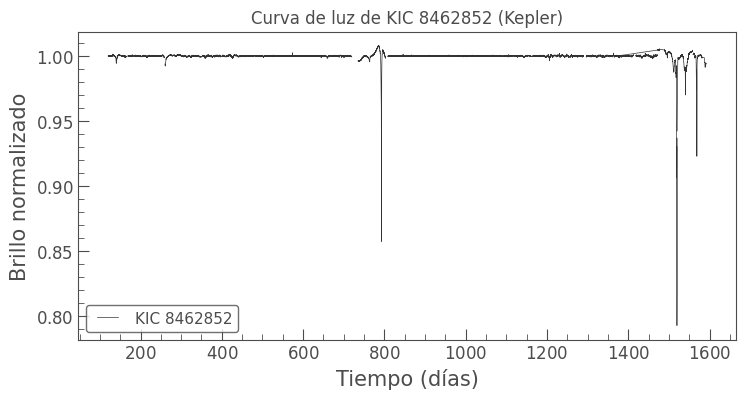

✅ Archivo guardado en: C:\Users\h_sar\PythonProject\notebooks\data\raw\curva_luz_KIC_8462852.csv
🔍 Buscando datos para KIC 12557548...


<Figure size 1000x500 with 0 Axes>

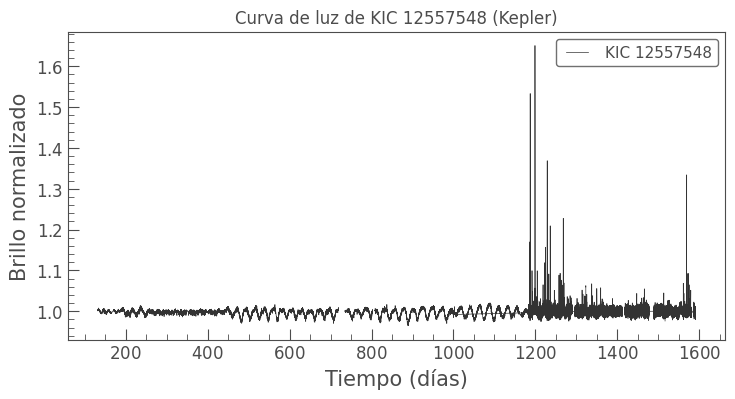

✅ Archivo guardado en: C:\Users\h_sar\PythonProject\notebooks\data\raw\curva_luz_KIC_12557548.csv
🔍 Buscando datos para KIC 3542116...


<Figure size 1000x500 with 0 Axes>

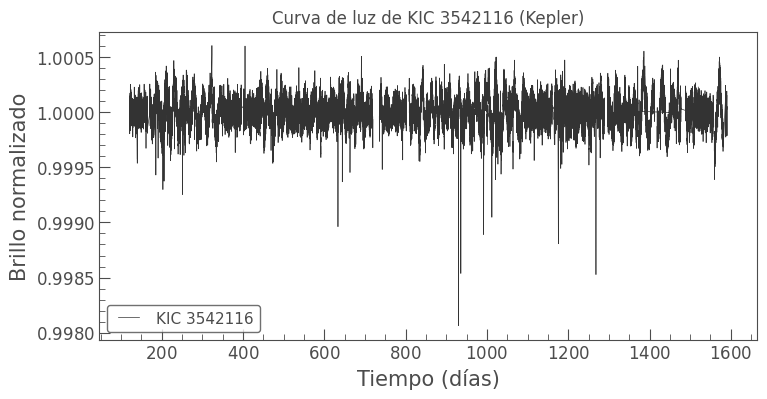

✅ Archivo guardado en: C:\Users\h_sar\PythonProject\notebooks\data\raw\curva_luz_KIC_3542116.csv
🔍 Buscando datos para Kepler-10...


<Figure size 1000x500 with 0 Axes>

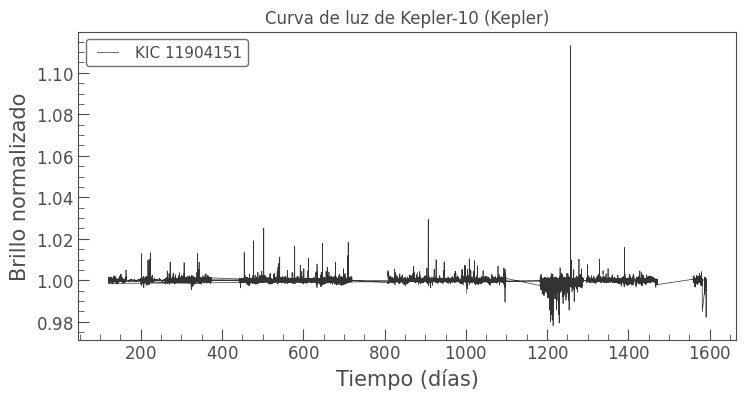

✅ Archivo guardado en: C:\Users\h_sar\PythonProject\notebooks\data\raw\curva_luz_Kepler-10.csv
🔍 Buscando datos para Kepler-22...


<Figure size 1000x500 with 0 Axes>

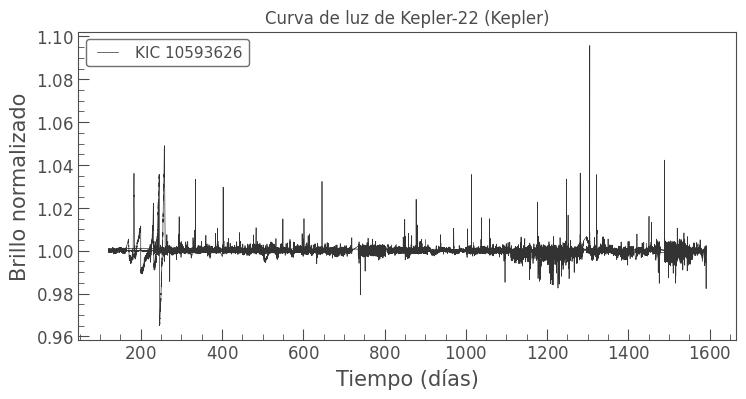

✅ Archivo guardado en: C:\Users\h_sar\PythonProject\notebooks\data\raw\curva_luz_Kepler-22.csv
🔍 Buscando datos para Kepler-62...


<Figure size 1000x500 with 0 Axes>

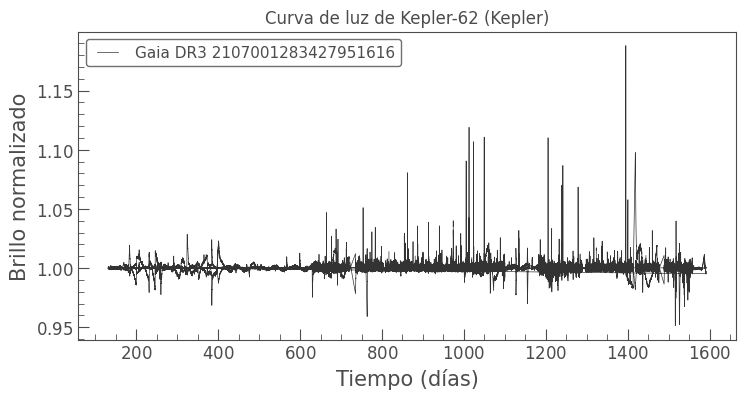

✅ Archivo guardado en: C:\Users\h_sar\PythonProject\notebooks\data\raw\curva_luz_Kepler-62.csv
🔍 Buscando datos para Kepler-186...


<Figure size 1000x500 with 0 Axes>

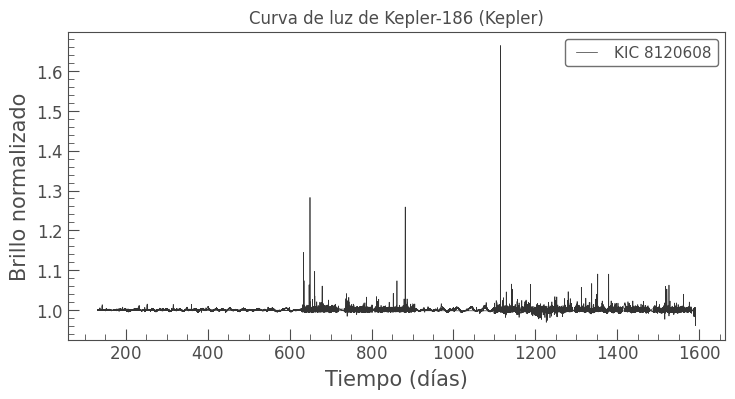

✅ Archivo guardado en: C:\Users\h_sar\PythonProject\notebooks\data\raw\curva_luz_Kepler-186.csv
🔍 Buscando datos para Kepler-452...


<Figure size 1000x500 with 0 Axes>

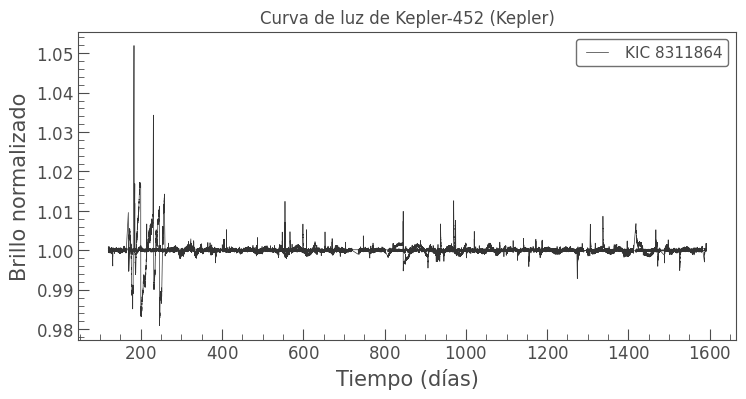

✅ Archivo guardado en: C:\Users\h_sar\PythonProject\notebooks\data\raw\curva_luz_Kepler-452.csv


In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import os

# Lista de estrellas a descargar (se eliminó KIC 3347538 y se agregó Kepler-10)
target_stars = [
    "KIC 8462852",  # Estrella de Tabby (megaestructuras alienígenas?)
    "KIC 12557548", # Estrella con variabilidad por polvo planetario
    "KIC 3542116",  # Estrella bien documentada en Kepler
    "Kepler-10",    # Sistema con planeta rocoso (Kepler-10b)
    "Kepler-22",    # Sistema con planeta en zona habitable (Kepler-22b)
    "Kepler-62",    # Sistema con exoplanetas en zona habitable (Kepler-62e, Kepler-62f)
    "Kepler-186",   # Sistema con Kepler-186f, un exoplaneta tipo Tierra
    "Kepler-452"    # Sistema con Kepler-452b, potencialmente similar a la Tierra
]

# Definir la carpeta donde guardar los datos
project_root = os.getcwd()  # Obtiene el directorio de trabajo actual
save_path = os.path.join(project_root, "data", "raw")
os.makedirs(save_path, exist_ok=True)  # Crea la carpeta si no existe

for target_star in target_stars:
    print(f"🔍 Buscando datos para {target_star}...")

    try:
        lc_collection = lk.search_lightcurve(target_star, mission="Kepler").download_all()

        if lc_collection is not None:
            lc = lc_collection.stitch()  # Unir datos fragmentados si hay varios archivos

            # Graficar la curva de luz
            plt.figure(figsize=(10, 5))
            lc.plot()
            plt.title(f"Curva de luz de {target_star} (Kepler)")
            plt.xlabel("Tiempo (días)")
            plt.ylabel("Brillo normalizado")
            plt.show()

            # Convertir la curva de luz en un DataFrame
            lc_df = lc.to_pandas()

            # Nombre del archivo de salida
            file_name = os.path.join(save_path, f"curva_luz_{target_star.replace(' ', '_')}.csv")

            # Guardar el archivo CSV
            lc_df.to_csv(file_name, index=False)
            print(f"✅ Archivo guardado en: {file_name}")

        else:
            print(f"❌ No se encontraron datos para {target_star}.")

    except Exception as e:
        print(f"⚠️ Error al buscar datos para {target_star}: {e}")
